<a href="https://colab.research.google.com/github/Plumz17/PP_FinalProject2/blob/main/PP_FinalProject2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pattern Recognition Project - Banana Variety and Ripeness Classification using Traditional ML Feature Extraction Methods
Arranged by:
*   Anders Emmanuel Tan (24/541351/PA/22964)
*   Danar Fathurahman (24/538200/PA/22828)

Description: Pada projek ini, kami akan menyusun pipeline lengkap menggunakan teknik-teknik ekstraksi fitur tradisional untuk mengklasifikasi jenis dan tingkat kematangan pisang di Indonesia. Dataset yang digunakan tersedia di tautan berikut: https://data.mendeley.com/datasets/h6n5srjjyw/1

## 0. Image Acquisition (Loading the Dataset)
Description:

In [ ]:
#Reset Runtime file
!rm -rf *

In [ ]:
# Import Important Libraries
import requests, os, zipfile, io, cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops, hog
from mahotas.features import zernike_moments

In [ ]:
# Import Dataset
URL = "https://data.mendeley.com/public-api/zip/h6n5srjjyw/download/1"
os.makedirs("/content/banana", exist_ok=True)

r = requests.get(URL, stream=True, headers={"User-Agent": "Mozilla/5.0"})
total = int(r.headers.get("content-length", 0))

with open("/content/banana.zip", "wb") as f, tqdm(total=total, unit="B", unit_scale=True) as bar:
  for chunk in r.iter_content(chunk_size=1024*1024):
    f.write(chunk)
    bar.update(len(chunk))

print("\n")
print("Download Complete!")

100%|██████████| 715M/715M [00:50<00:00, 14.3MB/s]



Download Complete!


In [ ]:
# Extract outer zip
BASE_DIR = "/content/banana/BananaID An image dataset of banana varieties and/"
IMG_DIR  = "/content/banana_images"
with zipfile.ZipFile("/content/banana.zip") as z:
    z.extractall("/content/banana/")

# Extract all four inner zips
inner_zips = {
  "Banana Variety Dataset.zip":"variety_original",
  "Banana Ripeness Dataset.zip":"ripeness_original",
  "Augmented Banana Variety Dataset.zip":"variety_augmented",
  "Augmented Banana Ripeness Dataset.zip":"ripeness_augmented",
}

for zip_name, out_folder in inner_zips.items():
  zip_path = os.path.join(BASE_DIR, zip_name)
  out_path = os.path.join(IMG_DIR, out_folder)
  print(f"Extracting {zip_name}...")
  with zipfile.ZipFile(zip_path) as z:
    z.extractall(out_path)

print("Extraction complete!")

Extracting Banana Variety Dataset.zip...
Extracting Banana Ripeness Dataset.zip...
Extracting Augmented Banana Variety Dataset.zip...
Extracting Augmented Banana Ripeness Dataset.zip...
Extraction complete!


## 1. Preprocessing


In [ ]:
#Variety Preprocessing
VARIETY_DIR = os.path.join(IMG_DIR, "variety_original/Banana Classification Dataset")

#Intialize array for images and labels
variety_images, variety_labels = [], []
#Name Banana's Variety class as their folder name
variety_class_names = sorted(os.listdir(VARIETY_DIR))
#Maps each class name with a number
variety_class_to_idx = {cls: idx for idx, cls in enumerate(variety_class_names)}

for class_name in tqdm(variety_class_names, desc="Preprocessing Banana Variety..."):
  #Get Filepath to specific variety class path
  class_path = os.path.join(VARIETY_DIR, class_name)
  for img_file in os.listdir(class_path):
    #Obtain image
    img = cv2.imread(os.path.join(class_path, img_file))
    if img is None:
      continue
    #Convert image to RGB for convinience sake
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    #Add image to image array
    variety_images.append(img)
    #Add label to label array
    variety_labels.append(variety_class_to_idx[class_name])

#Normalize and convert into a numpy array
variety_images = np.array(variety_images, dtype=np.uint8)
variety_labels = np.array(variety_labels)

print(f"Images : {variety_images.shape}")
print(f"Labels : {variety_labels.shape}")
print(f"Classes: {variety_class_names}")

Preprocessing Banana Variety...: 100%|██████████| 5/5 [00:01<00:00,  3.49it/s]

Images : (1960, 256, 384, 3)
Labels : (1960,)
Classes: ['Ambon', 'Cavendish', 'Mas', 'Raja', 'Saba']


In [ ]:
#Ripeness Preprocessing
RIPENESS_DIR = os.path.join(IMG_DIR, "ripeness_original/Banana Ripeness Classification Dataset")

#Intialize array for images and labels
ripeness_images, ripeness_labels = [], []

#Name Banana's Ripeness class as their folder name
ripeness_class_names = sorted(os.listdir(RIPENESS_DIR))
#Maps each class name with a number
ripeness_class_to_idx = {cls: idx for idx, cls in enumerate(ripeness_class_names)}

for class_name in tqdm(ripeness_class_names, desc="Preprocessing Banana Ripeness..."):
  #Get Filepath to specific ripeness class path
  class_path = os.path.join(RIPENESS_DIR, class_name)
  for img_file in os.listdir(class_path):
    #Obtain image
    img = cv2.imread(os.path.join(class_path, img_file))
    if img is None:
      continue
    #Convert image to RGB for convinience sake
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    #Add image to image array
    ripeness_images.append(img)
    #Add label to label array
    ripeness_labels.append(ripeness_class_to_idx[class_name])

#Normalize and convert into a numpy array
ripeness_images = np.array(ripeness_images, dtype=np.uint8)
ripeness_labels = np.array(ripeness_labels)

print(f"Images : {ripeness_images.shape}")
print(f"Labels : {ripeness_labels.shape}")
print(f"Classes: {ripeness_class_names}")

Preprocessing Banana Ripeness...: 100%|██████████| 4/4 [00:01<00:00,  3.08it/s]

Images : (1960, 256, 384, 3)
Labels : (1960,)
Classes: ['Half_Ripe', 'Overripe', 'Ripe', 'Unripe']


In [ ]:
def show(before, after=None, title2= "Processed"): # Helper function to check the before and after of the processing
  plt.figure(figsize=(10,5))

  # Show original
  plt.subplot(1,2,1)
  plt.imshow(before, cmap='gray', vmin=0, vmax=255) #vmin and max to preserve original image's contrast
  plt.title("Original")
  plt.axis("off")

  # Show processed
  if after is not None:
    plt.subplot(1,2,2)
    plt.imshow(after, cmap='gray', vmin=0, vmax=255)
    plt.title(title2)
    plt.axis("off")

  plt.show()

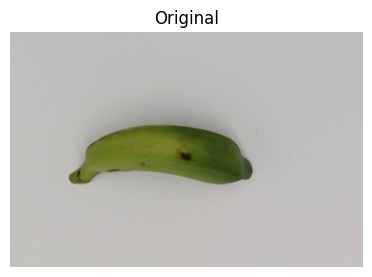

np.int64(3)

In [ ]:
show(ripeness_images[1959])
ripeness_labels[1959]

## 2. Image Enhancement

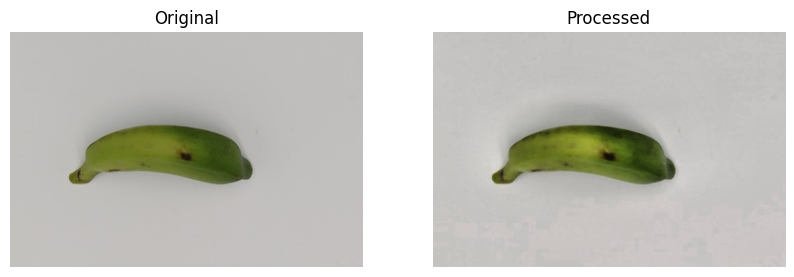

In [ ]:
def image_enhancement(img):
  # 1. Convert to HSV
  hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

  # 2. Split channels
  h, s, v = cv2.split(hsv)

  # 3. Median Blur
  v_enhanced = cv2.medianBlur(v, 3)

  # 4. Apply CLAHE to V channel (brightness)
  clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
  v_enhanced = clahe.apply(v_enhanced)

  # 5. Merge back
  hsv_enhanced = cv2.merge([h, s, v_enhanced])

  # 6. Convert back to BGR (for visualization / further processing)
  enhanced_img = cv2.cvtColor(hsv_enhanced, cv2.COLOR_HSV2RGB)

  return enhanced_img


show(ripeness_images[1959], image_enhancement(ripeness_images[1959]))

## 3. Image Segmentation

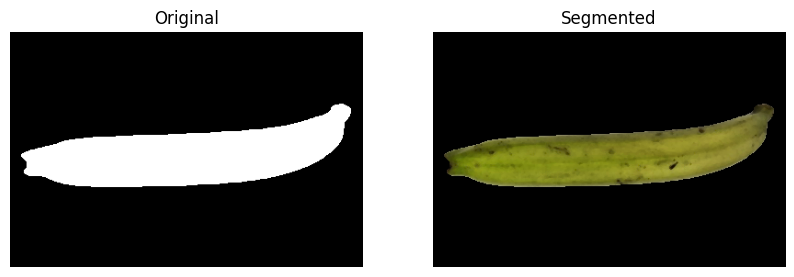

In [ ]:
def segment_banana(img):
  # Convert to HSV
  hsv  = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
  #Mask the section of the image with banana colors
  mask = cv2.inRange(hsv, np.array([15, 60, 60]), np.array([85, 255, 255]))

  # Apply Morphological Processing
  kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
  mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=3)
  mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,kernel)
  return mask, cv2.bitwise_and(img, img, mask=mask)

# Apply and visualise
mask, segmented = segment_banana(image_enhancement(variety_images[0]))
show(mask, segmented, title2="Segmented")

## 4. Feature Extraction

In [ ]:
def preprocess(img): # Helper function to apply the previous steps
  enhanced        = image_enhancement(img)
  mask, segmented = segment_banana(enhanced)
  return segmented, mask

In [ ]:
def extract_ripeness_features(img):
  segmented, mask = preprocess(img)
  hsv = cv2.cvtColor(segmented, cv2.COLOR_RGB2HSV)

  # 1. HSV histograms (32 bins per channel)
  hist_feat = []
  for ch in range(3):
    hist = cv2.calcHist([hsv], [ch], mask, [32], [0, 256]).flatten()
    hist_feat.extend(hist / (hist.sum() + 1e-6))

  # 2. Color Moments (mean, variance, skewness per channel)
  moment_feat = []
  for ch in range(3):
    px = hsv[:,:,ch][mask > 0].astype(np.float32)
    mean = px.mean()
    var  = px.var()
    skew = float(np.mean(((px - mean) / (px.std() + 1e-6)) ** 3))
    moment_feat.extend([mean, var, skew])

  # 3. LBP histogram
  gray     = cv2.cvtColor(segmented, cv2.COLOR_RGB2GRAY)
  lbp      = local_binary_pattern(gray, P=8, R=1, method="uniform")
  lbp_hist, _ = np.histogram(lbp[mask > 0], bins=10, range=(0, 10), density=True)

  return np.array(hist_feat + moment_feat + lbp_hist.tolist(), dtype=np.float32)

extract_ripeness_features(image_enhancement(variety_images[0]))

array([ 0.00000000e+00,  0.00000000e+00,  2.64133979e-03,  6.98662460e-01,
        2.98696190e-01,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  2.64133979e-03,
        5.78846782e-03,  6.23805774e-03,  6.80004479e-03,  7.02483999e-03,
        9.83477570e-03,  9.72237810e-03,  1.54546481e-02,  1.42182754e-02,
        1.92761607e-02,  2.49522310e-02,  3.33820395e-02,  4.36102040e-02,
        7.48004913e-02,  

In [ ]:
def extract_variety_features(img):
  segmented, mask = preprocess(img)
  gray = cv2.cvtColor(segmented, cv2.COLOR_RGB2GRAY)

  # 1. GLCM Haralick (4 angles)
  glcm = graycomatrix(gray, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                      levels=256, symmetric=True, normed=True)
  glcm_feat = np.concatenate([graycoprops(glcm, prop).flatten()
                              for prop in ['contrast', 'dissimilarity',
                                           'homogeneity', 'energy', 'correlation']])

  # 2. HOG
  gray_resized = cv2.resize(gray, (128, 128))
  hog_feat = hog(gray_resized, orientations=8, pixels_per_cell=(16,16),
                 cells_per_block=(2,2), feature_vector=True)

  # 3. Hu Moments (log-transformed)
  moments = cv2.moments(mask)
  hu = cv2.HuMoments(moments).flatten()
  hu_feat = -np.sign(hu) * np.log10(np.abs(hu) + 1e-10)

  # 4. Zernike Moments (order 8)
  mask_resized = cv2.resize(mask, (128, 128))
  zernike_feat = zernike_moments(mask_resized, radius=64, degree=8)

  # 5. Contour descriptors
  contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
  if contours:
    cnt      = max(contours, key=cv2.contourArea)
    area     = cv2.contourArea(cnt)
    x,y,w,h  = cv2.boundingRect(cnt)
    aspect   = w / (h + 1e-6)
    extent   = area / (w * h + 1e-6)
    hull     = cv2.convexHull(cnt)
    solidity = area / (cv2.contourArea(hull) + 1e-6)
    contour_feat = [area, aspect, extent, solidity]
  else:
    contour_feat = [0, 0, 0, 0]

  return np.concatenate([glcm_feat, hog_feat, hu_feat, zernike_feat,
                         np.array(contour_feat)]).astype(np.float32)
extract_variety_features(image_enhancement(variety_images[3]))

array([ 25.838324 , 108.021645 , 102.111664 , ...,   5.0166664,
         0.6921373,   0.9539072], dtype=float32)

In [ ]:
X_variety  = np.array([extract_variety_features(img)  for img in tqdm(variety_images,  desc="Variety...")])
X_ripeness = np.array([extract_ripeness_features(img) for img in tqdm(ripeness_images, desc="Ripeness...")])

print(f"Variety  feature matrix: {X_variety.shape}")
print(f"Ripeness feature matrix: {X_ripeness.shape}")

Ripeness...: 100%|██████████| 1960/1960 [00:40<00:00, 47.87it/s]

Variety  feature matrix: (1960, 1624)
Ripeness feature matrix: (1960, 115)


## 5. Modelling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler_variety  = StandardScaler()
scaler_ripeness = StandardScaler()

X_variety_scaled  = scaler_variety.fit_transform(X_variety)
X_ripeness_scaled = scaler_ripeness.fit_transform(X_ripeness)

print(f"Variety scaled: {X_variety_scaled.shape}")
print(f"Ripeness scaled: {X_ripeness_scaled.shape}")

Variety  scaled: (1960, 1624)
Ripeness scaled: (1960, 115)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Train/Test Split
X_var_train, X_var_test, y_var_train, y_var_test = train_test_split(
    X_variety_scaled, variety_labels, test_size=0.2, random_state=42, stratify=variety_labels)

X_rip_train, X_rip_test, y_rip_train, y_rip_test = train_test_split(
    X_ripeness_scaled, ripeness_labels, test_size=0.2, random_state=42, stratify=ripeness_labels)

# Define Models
models = {
    "SVM"          : SVC(kernel="rbf", C=10, gamma="scale"),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN"          : KNeighborsClassifier(n_neighbors=5),
}

# Train and store
variety_models  = {}
ripeness_models = {}

for name, model in models.items():
    # Variety
    m_var = model.__class__(**model.get_params())
    m_var.fit(X_var_train, y_var_train)
    variety_models[name] = m_var

    # Ripeness
    m_rip = model.__class__(**model.get_params())
    m_rip.fit(X_rip_train, y_rip_train)
    ripeness_models[name] = m_rip

    print(f"{name} trained!")

SVM trained ✓
Random Forest trained ✓
KNN trained ✓



 Variety Classification

── SVM ──
              precision    recall  f1-score   support

       Ambon       0.79      0.89      0.84        94
   Cavendish       0.69      0.72      0.71        76
         Mas       0.96      0.95      0.95        75
        Raja       0.79      0.69      0.74        85
        Saba       0.79      0.71      0.75        62

    accuracy                           0.80       392
   macro avg       0.80      0.79      0.80       392
weighted avg       0.80      0.80      0.80       392



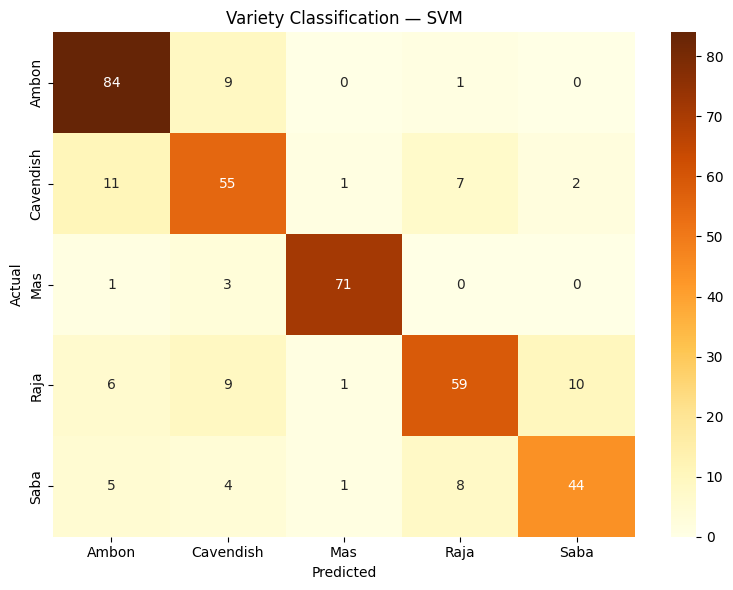


── Random Forest ──
              precision    recall  f1-score   support

       Ambon       0.85      0.94      0.89        94
   Cavendish       0.73      0.75      0.74        76
         Mas       0.97      0.95      0.96        75
        Raja       0.76      0.81      0.78        85
        Saba       0.83      0.63      0.72        62

    accuracy                           0.83       392
   macro avg       0.83      0.81      0.82       392
weighted avg       0.83      0.83      0.82       392



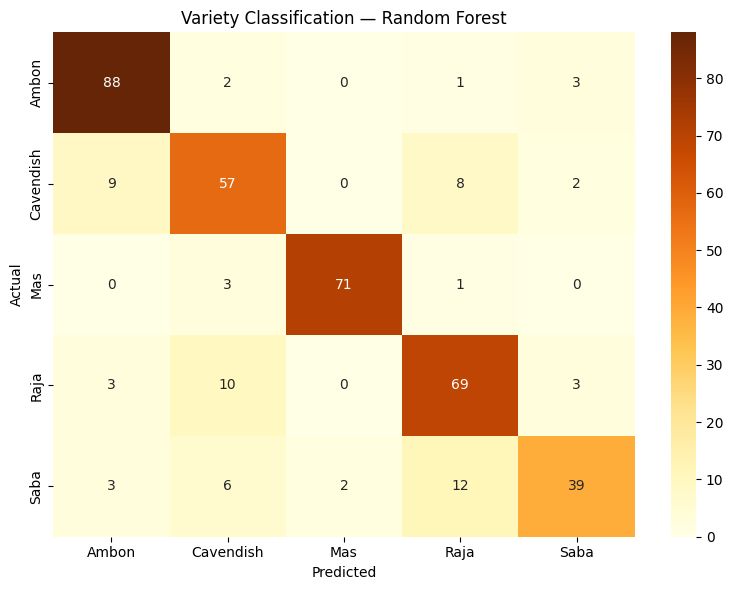


── KNN ──
              precision    recall  f1-score   support

       Ambon       0.78      0.81      0.79        94
   Cavendish       0.46      0.47      0.47        76
         Mas       0.80      1.00      0.89        75
        Raja       0.66      0.66      0.66        85
        Saba       0.65      0.39      0.48        62

    accuracy                           0.68       392
   macro avg       0.67      0.67      0.66       392
weighted avg       0.67      0.68      0.67       392



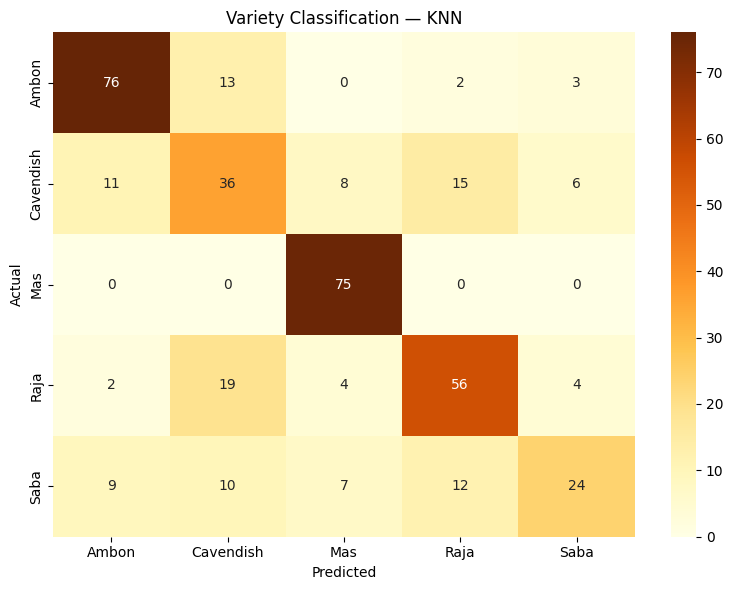


 Ripeness Classification

── SVM ──
              precision    recall  f1-score   support

   Half_Ripe       0.82      0.77      0.80        97
    Overripe       0.78      0.83      0.81        90
        Ripe       0.78      0.77      0.78       123
      Unripe       0.92      0.93      0.92        82

    accuracy                           0.82       392
   macro avg       0.82      0.83      0.83       392
weighted avg       0.82      0.82      0.82       392



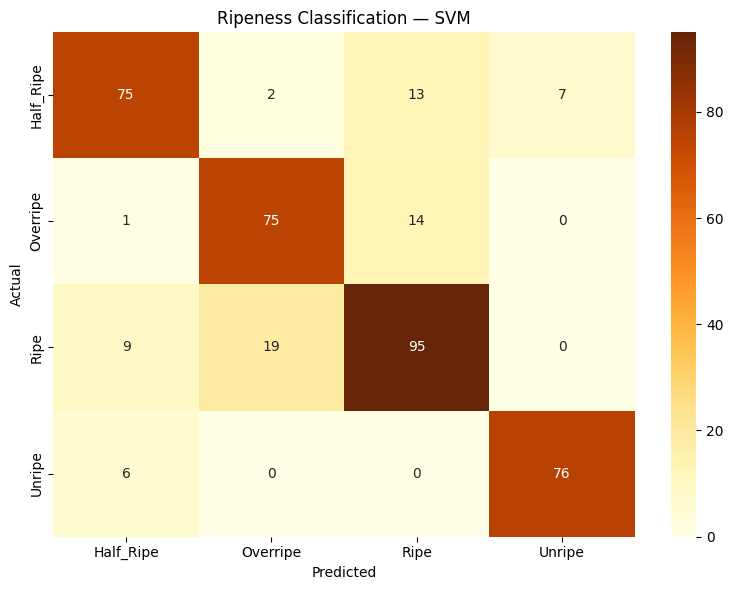


── Random Forest ──
              precision    recall  f1-score   support

   Half_Ripe       0.79      0.78      0.79        97
    Overripe       0.84      0.76      0.80        90
        Ripe       0.78      0.82      0.80       123
      Unripe       0.88      0.91      0.90        82

    accuracy                           0.82       392
   macro avg       0.82      0.82      0.82       392
weighted avg       0.82      0.82      0.82       392



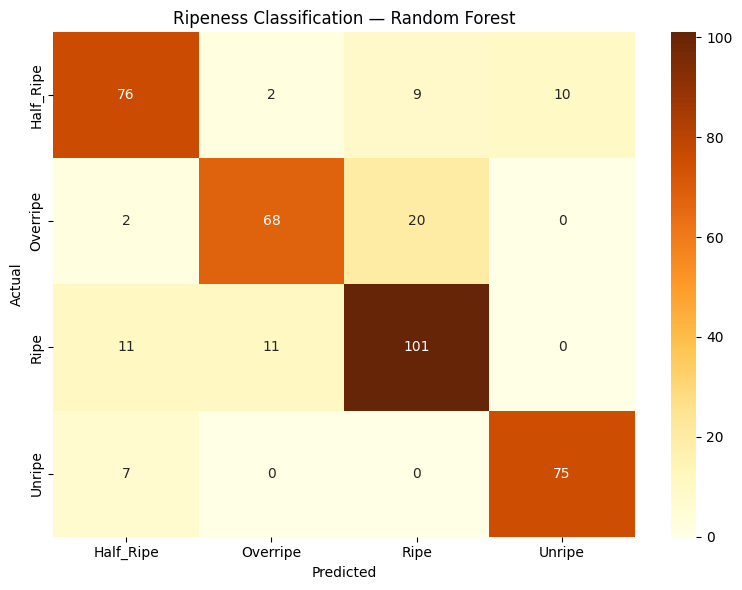


── KNN ──
              precision    recall  f1-score   support

   Half_Ripe       0.68      0.72      0.70        97
    Overripe       0.72      0.80      0.76        90
        Ripe       0.78      0.72      0.75       123
      Unripe       0.89      0.82      0.85        82

    accuracy                           0.76       392
   macro avg       0.77      0.77      0.77       392
weighted avg       0.77      0.76      0.76       392



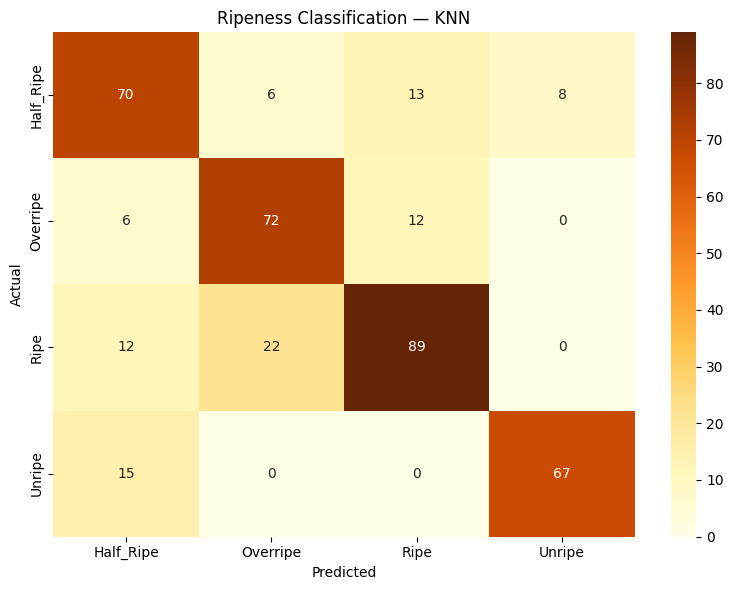

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

def evaluate(models, X_test, y_test, class_names, task_name):
    print(f"\n{'='*50}")
    print(f" {task_name}")
    print(f"{'='*50}")
    for name, model in models.items():
        y_pred = model.predict(X_test)
        print(f"\n── {name} ──")
        print(classification_report(y_test, y_pred, target_names=class_names))

        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt="d", cmap="YlOrBr",
                    xticklabels=class_names, yticklabels=class_names)
        plt.title(f"{task_name} — {name}")
        plt.ylabel("Actual")
        plt.xlabel("Predicted")
        plt.tight_layout()
        plt.show()

# ── Run evaluation ────────────────────────────────────────────────────────────
evaluate(variety_models,  X_var_test, y_var_test,
         variety_class_names,  "Variety Classification")

evaluate(ripeness_models, X_rip_test, y_rip_test,
         ripeness_class_names, "Ripeness Classification")